# Churn Prediction — Notebook
**Dataset:** Telecom customer churn data (667 rows, 20 columns)

This notebook trains a Logistic Regression model to predict whether a customer will leave (churn).

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

print('Libraries loaded!')

Libraries loaded!


---
## 2. Load Data

In [2]:
df = pd.read_csv('../data/raw/churn-bigml-20.csv')

print('Shape:', df.shape)
df.head()

Shape: (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


---
## 3. Basic Exploration

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

In [4]:

print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [5]:

churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('Class distribution (counts):')
print(churn_counts)
print()
print('Class distribution (%):')
print(churn_pct.round(2))

Class distribution (counts):
Churn
False    572
True      95
Name: count, dtype: int64

Class distribution (%):
Churn
False    85.76
True     14.24
Name: proportion, dtype: float64


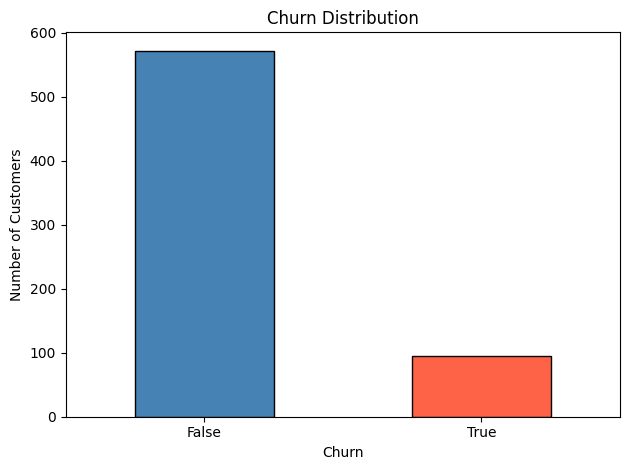

In [6]:

churn_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Why is this a problem?

About **85% of customers did NOT churn**, and only **~15% did**.

This is called a **class imbalance** — one group is much bigger than the other.

Here's why this matters:
- If a model just predicts **"No churn"** for every single customer, it would still get **85% accuracy**.
- That sounds good, but it completely **misses every churned customer** — which is the whole point.
- This is why accuracy alone is **misleading** for imbalanced datasets.
- We need to look at **Recall** — how many actual churners we correctly caught.

---
## 4. Remove 'State' Column

In [7]:

df = df.drop(columns=['State'])

print('Remaining columns:', df.shape[1])
print(df.columns.tolist())

Remaining columns: 19
['Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']


---
## 5. Encode Categorical Variables

In [8]:

df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan']    = df['Voice mail plan'].map({'Yes': 1, 'No': 0})

df['Churn'] = df['Churn'].map({True: 1, False: 0})

print('Encoding done!')
df[['International plan', 'Voice mail plan', 'Churn']].head()

Encoding done!


,International plan,Voice mail plan,Churn
0,0,0,0
1,0,0,1
2,0,0,1
3,0,0,0
4,0,0,0


---
## 6. Train-Test Split (Stratified)

In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size :', X_train.shape[0])
print('Test set size     :', X_test.shape[0])
print()
print('Churn rate in train:', y_train.mean().round(3))
print('Churn rate in test :', y_test.mean().round(3))

Training set size : 533
Test set size     : 134

Churn rate in train: 0.143
Churn rate in test : 0.142


---
## 7. Scaling

In [10]:
scaler = MinMaxScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling done!')
print('Min after scaling:', X_train_scaled.min().round(2))
print('Max after scaling:', X_train_scaled.max().round(2))

Scaling done!
Min after scaling: 0.0
Max after scaling: 1.0


---
## 8. Train Logistic Regression

In [11]:

log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

print('Model trained!')

Model trained!


---
## 9. Evaluate the Model

In [12]:
y_pred  = log_model.predict(X_test_scaled)
y_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print('--- Evaluation at default threshold (0.5) ---')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.3f}')
print(f'Recall    : {recall_score(y_test, y_pred):.3f}')
print(f'Precision : {precision_score(y_test, y_pred):.3f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_proba):.3f}')

--- Evaluation at default threshold (0.5) ---
Accuracy  : 0.806
Recall    : 0.684
Precision : 0.394
F1 Score  : 0.500
ROC-AUC   : 0.819


### What does each metric mean?

- **Accuracy** — out of all customers, how many did we predict correctly? (misleading for imbalanced data)
- **Recall** — out of all actual churners, how many did we catch? ← **this is the most important one here**
- **Precision** — out of everyone we flagged as a churner, how many actually churned?
- **F1 Score** — a balance between Recall and Precision
- **ROC-AUC** — overall ability of the model to separate churners from non-churners (closer to 1 = better)

**Why Recall matters most:** If we miss a churner, we lose that customer. A false alarm (flagging someone who won't churn) just means an extra retention call — much less costly.

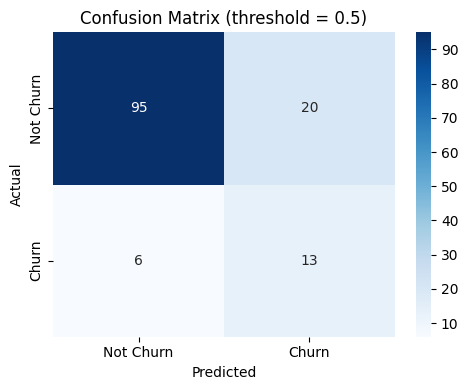

In [13]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix (threshold = 0.5)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 10. ROC Curve

The **ROC (Receiver Operating Characteristic) curve** plots the True Positive Rate (Recall) against the False Positive Rate at every possible threshold.

- **AUC (Area Under the Curve)** close to 1 = excellent model discrimination
- The dashed diagonal line represents a random classifier (AUC = 0.5)
- Our model's curve being far above the diagonal means it's meaningfully better than chance

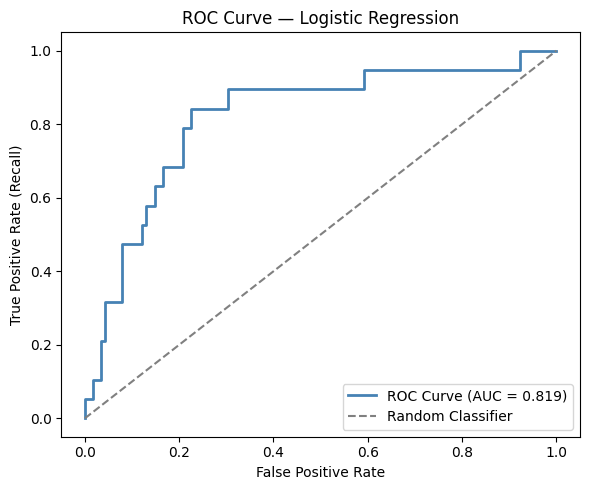

AUC Score: 0.819


In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'AUC Score: {auc_score:.3f}')

---
## 11. Threshold Tuning

By default, the model predicts "Churn" when the probability is above **0.5**.

But since we care most about **catching churners**, we can lower the threshold to **0.3**.
That means: if the model is even **30% sure** a customer might churn, we flag them.

The tradeoff: we catch more real churners, but we also get more false alarms.

--- Evaluation at threshold = 0.3 ---
Accuracy  : 0.634
Recall    : 0.895
Precision : 0.266
F1 Score  : 0.410


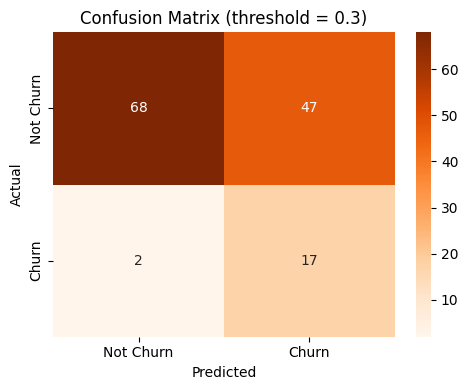

In [15]:
threshold = 0.3
y_pred_adjusted = (y_proba >= threshold).astype(int)

print(f'--- Evaluation at threshold = {threshold} ---')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_adjusted):.3f}')
print(f'Recall    : {recall_score(y_test, y_pred_adjusted):.3f}')
print(f'Precision : {precision_score(y_test, y_pred_adjusted):.3f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_adjusted):.3f}')

cm2 = confusion_matrix(y_test, y_pred_adjusted)

plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix (threshold = {threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## Save Model and Scaler

In [16]:
joblib.dump(log_model, '../models/modellog.joblib')
joblib.dump(scaler,    '../models/minmaxscaler.joblib')

print('Model saved  → models/modellog.joblib')
print('Scaler saved → models/minmaxscaler.joblib')

Model saved  → models/modellog.joblib
Scaler saved → models/minmaxscaler.joblib


### Why do we save both?

**The model** is saved so we don't have to retrain every time we want to make a prediction.

**The scaler** is saved because it's just as important as the model.

During training, the scaler learned the minimum and maximum values of each column.
When a new customer comes in, we need to scale their data using **those same values** — not new ones.

If we used a different scaler (or no scaler at all), the numbers would be in a completely different range,
and the model would make wrong predictions.

Simple way to remember it: **the scaler and model are a pair — they always travel together.**